# Export Inference with HUWNG Dataset

## Updates for HUWNG Dataset:
- Uses HUWNG dataset format (.npy files instead of HDF5)
- Auto-loads DINOv2 embeddings from HUWNG folder
- No need for datalist JSON or image_ids mapping
- fMRI and embeddings are pre-aligned

## Tasks:
1. **Part 1**: Config & Setup  
2. **Part 2**: Load HUWNG Test Dataset
3. **Part 3**: Model Inference & Save as NIfTI
4. **Part 4**: Visualization

Note: Image export is skipped (HUWNG doesn't include stimulus images)

---
# Part 1: Config & Setup

In [1]:
import sys
sys.path.insert(0, '..')

import os
import json
import h5py
import numpy as np
import torch
import nibabel as nib
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

print("Libraries loaded!")

Libraries loaded!


In [2]:
# ==================== ALL CONFIG ====================

# HUWNG Dataset path
HUWNG_BASE_PATH = "../dataset/huwng"
SUBJECT = 1

# Model checkpoint
CHECKPOINT_PATH = "../checkpoints/_2hierarchical_v3.1_subj01_30vpc/best_model.pth"

# Model params (must match training config!)
VOXELS_PER_CLUSTER = 30
ROI_TOP_K_PERCENT = 0.7
DINOV2_LAYER = -1  # Which DINOv2 layer to use (-1 = last layer)

# Output directory
OUTPUT_NII_DIR = "../outputs/inference_results_huwng"

# Inference settings
INFERENCE_INDICES = [786, 694, 579, 541, 372, 271, 196, 32]
# INFERENCE_INDICES = [115, 201, 262, 323, 459, 788, 867, 969]
# INFERENCE_INDICES = [0, 1, 5, 10, 50, 100, 200, 500]  # Examples from test set

# Optional: brain mask for 3D NIfTI
BRAIN_MASK_PATH = None

# Create output directory
os.makedirs(OUTPUT_NII_DIR, exist_ok=True)

print("Config loaded!")
print(f"  HUWNG dataset: {HUWNG_BASE_PATH}")
print(f"  Subject: {SUBJECT}")
print(f"  Output NIfTI:  {OUTPUT_NII_DIR}")
print(f"  Checkpoint: {CHECKPOINT_PATH}")

Config loaded!
  HUWNG dataset: ../dataset/huwng
  Subject: 1
  Output NIfTI:  ../outputs/inference_results_huwng
  Checkpoint: ../checkpoints/_2hierarchical_v3.1_subj01_30vpc/best_model.pth


---
# Part 2: Load HUWNG Test Dataset

HUWNG dataset includes pre-aligned embeddings, so no image export or verification needed.

In [3]:
# Load HUWNG test dataset
from data.dataset_v7_h import load_neuroflux_data_v7h

print("Loading HUWNG test dataset...")
test_dataset = load_neuroflux_data_v7h(
    huwng_base_path=HUWNG_BASE_PATH,
    embeddings_path=None,  # Auto-load from HUWNG folder
    subjects=[SUBJECT],
    split='test',
    average_trials=True,  # Average 3 trials -> 1 sample per image
    voxels_per_cluster=VOXELS_PER_CLUSTER,
    roi_top_k_percent=ROI_TOP_K_PERCENT,
    augment_noise=False,
    noise_std=0.0,
    dinov2_layer=DINOV2_LAYER,
)

print(f"\nTest dataset size: {len(test_dataset)}")
print(f"Num ROIs: {test_dataset.num_rois}")

# Verify sample shapes
sample = test_dataset[0]
print(f"\nSample shapes:")
print(f"  fmri: {sample['fmri'].shape}")
print(f"  cls_token: {sample['cls_token'].shape}")
print(f"  patch_tokens: {sample['patch_tokens'].shape}")
print(f"  roi_means: {sample['roi_means'].shape}")
print(f"  image_id: {sample['image_id']}")

print(f"\n✅ Dataset loaded successfully!")

Loading HUWNG test dataset...
Auto-detected embeddings path: ../dataset/huwng/subj01/nsd_dinov2_vitb14_multilayer_test_sub1.npy
Loading test embeddings from ../dataset/huwng/subj01/nsd_dinov2_vitb14_multilayer_test_sub1.npy...
  Multilayer embeddings detected: (1000, 4, 257, 768)
  Using layer -1 (0-indexed, -1=last)
  Selected shape: (1000, 257, 768)

Processing Subject 1 for test split...
  Loading fMRI from ../dataset/huwng/subj01/nsd_test_fmri_zscore_sub1.npy...
  Loaded shape: (1000, 3, 15724)
  Averaging 3 trials per image...
  After averaging: (1000, 15724)
  Test fMRI: (1000, 15724), 1000 unique images
Using CLS + patches format: (1000, 257, 768)
NeuroFluxDatasetV7H: 1000 samples, 15724 voxels → 524 ROIs (30 voxels/ROI, top-70%) [dtype=float32]

Test dataset size: 1000
Num ROIs: 524

Sample shapes:
  fmri: torch.Size([15724])
  cls_token: torch.Size([768])
  patch_tokens: torch.Size([256, 768])
  roi_means: torch.Size([524])
  image_id: 0

✅ Dataset loaded successfully!


---
# Part 3: Model Inference & Save as NIfTI

In [4]:
# Load model
from model.hierarchical_v3_1 import HierarchicalARM_V3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = HierarchicalARM_V3(
    cls_dim=768,
    patch_dim=768,
    num_patches=256,
    fmri_dim=15724,
    voxels_per_cluster=VOXELS_PER_CLUSTER,
).to(device)

# Load checkpoint
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✅ Loaded checkpoint from {CHECKPOINT_PATH}")
        if 'epoch' in checkpoint:
            print(f"   Epoch: {checkpoint['epoch']}")
        if 'val_pearson' in checkpoint:
            print(f"   Val Pearson: {checkpoint['val_pearson']:.4f}")
    else:
        model.load_state_dict(checkpoint)
        print(f"✅ Loaded checkpoint from {CHECKPOINT_PATH}")
else:
    print(f"⚠️ WARNING: Checkpoint not found at {CHECKPOINT_PATH}")
    print("Using random weights - results will be meaningless!")

model.eval()
print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model ROIs: {model.num_rois}")

Using device: cuda
DualStreamMambaStage1: 15724 voxels → 524 ROIs (30 voxels/ROI, 4 remainder)
✅ Loaded checkpoint from ../checkpoints/_2hierarchical_v3.1_subj01_30vpc/best_model.pth

Model parameters: 288,016,583
Model ROIs: 524


In [5]:
def save_fmri_as_nii(fmri_vector, output_path, brain_mask_nii=None):
    """Save 1D fMRI vector as NIfTI file."""
    if brain_mask_nii is not None:
        mask_data = brain_mask_nii.get_fdata().astype(bool)
        volume = np.zeros(mask_data.shape, dtype=np.float32)
        volume[mask_data] = fmri_vector
        nii = nib.Nifti1Image(volume, brain_mask_nii.affine, brain_mask_nii.header)
    else:
        # Save as 1D NIfTI (flatten format)
        volume = fmri_vector.reshape(-1, 1, 1)
        affine = np.eye(4)
        nii = nib.Nifti1Image(volume.astype(np.float32), affine)
    nib.save(nii, output_path)


def run_inference_multi_trials(model, dataset, indices, output_dir, brain_mask_nii=None, num_trials=3, enable_dropout=True):
    """
    Run inference multiple trials on the same features to check variability.
    
    Args:
        model: The neural network model
        dataset: Test dataset
        indices: List of sample indices to process
        output_dir: Directory to save NIfTI files
        brain_mask_nii: Optional brain mask for 3D NIfTI
        num_trials: Number of inference trials per sample (default: 3)
        enable_dropout: Enable dropout during inference for stochastic predictions
    
    Returns:
        results: Dictionary with predictions from all trials and their statistics
    """
    device = next(model.parameters()).device
    results = {}
    
    # Set model to train mode if we want dropout, otherwise eval mode
    if enable_dropout:
        model.train()  # Enable dropout
        print(f"⚠️ Model in TRAIN mode (dropout enabled) for stochastic inference")
    else:
        model.eval()
        print(f"✅ Model in EVAL mode (deterministic inference)")
    
    print(f"Running {num_trials}-trial inference on {len(indices)} samples...")
    
    with torch.no_grad() if not enable_dropout else torch.enable_grad():
        for idx in tqdm(indices, desc="Multi-trial Inference"):
            if idx < 0 or idx >= len(dataset):
                print(f"⚠️ WARNING: Index {idx} out of range [0, {len(dataset)-1}], skipping...")
                continue
            
            sample = dataset[idx]
            cls_token = sample['cls_token'].unsqueeze(0).to(device)
            patch_tokens = sample['patch_tokens'].unsqueeze(0).to(device)
            gt_fmri = sample['fmri'].detach().numpy()
            
            # Run multiple trials
            trial_predictions = []
            
            for trial in range(num_trials):
                # Model returns (guidance, pred_voxels, kl_loss) for stage=2
                _, pred_voxels, _ = model(cls_token, patch_tokens, stage=2)
                pred_fmri = pred_voxels.cpu().detach().numpy().squeeze()
                trial_predictions.append(pred_fmri)
                
                # Save individual trial
                trial_pred_path = os.path.join(output_dir, f"sample_{idx:04d}_trial{trial+1}_pred.nii")
                save_fmri_as_nii(pred_fmri, trial_pred_path, brain_mask_nii)
            
            # Convert to array for statistics
            trial_predictions = np.array(trial_predictions)  # shape: (num_trials, num_voxels)
            
            # Calculate mean and std across trials
            mean_pred = np.mean(trial_predictions, axis=0)
            std_pred = np.std(trial_predictions, axis=0)
            
            # Calculate variance metrics
            mean_std_across_voxels = np.mean(std_pred)
            max_std_across_voxels = np.max(std_pred)
            
            # Calculate correlation for each trial
            trial_correlations = []
            for trial_pred in trial_predictions:
                corr = np.corrcoef(gt_fmri, trial_pred)[0, 1]
                trial_correlations.append(corr)
            
            # Calculate correlation for mean prediction
            mean_corr = np.corrcoef(gt_fmri, mean_pred)[0, 1]
            
            # Save ground truth (once)
            gt_path = os.path.join(output_dir, f"sample_{idx:04d}_gt.nii")
            save_fmri_as_nii(gt_fmri, gt_path, brain_mask_nii)
            
            # Save mean prediction
            mean_pred_path = os.path.join(output_dir, f"sample_{idx:04d}_mean_pred.nii")
            save_fmri_as_nii(mean_pred, mean_pred_path, brain_mask_nii)
            
            # Save std map
            std_pred_path = os.path.join(output_dir, f"sample_{idx:04d}_std_pred.nii")
            save_fmri_as_nii(std_pred, std_pred_path, brain_mask_nii)
            
            results[idx] = {
                'gt_path': gt_path,
                'mean_pred_path': mean_pred_path,
                'std_pred_path': std_pred_path,
                'trial_pred_paths': [os.path.join(output_dir, f"sample_{idx:04d}_trial{t+1}_pred.nii") 
                                    for t in range(num_trials)],
                'trial_correlations': trial_correlations,
                'mean_correlation': mean_corr,
                'trial_correlation_mean': np.mean(trial_correlations),
                'trial_correlation_std': np.std(trial_correlations),
                'prediction_std_mean': mean_std_across_voxels,
                'prediction_std_max': max_std_across_voxels,
                'image_id': sample['image_id'],
            }
    
    # Restore model to eval mode
    model.eval()
    
    return results


def run_inference(model, dataset, indices, output_dir, brain_mask_nii=None):
    """Run inference on selected indices and save results (single trial)."""
    device = next(model.parameters()).device
    results = {}
    
    print(f"Running inference on {len(indices)} samples...")
    
    with torch.no_grad():
        for idx in tqdm(indices, desc="Inference"):
            if idx < 0 or idx >= len(dataset):
                print(f"⚠️ WARNING: Index {idx} out of range [0, {len(dataset)-1}], skipping...")
                continue
            
            sample = dataset[idx]
            cls_token = sample['cls_token'].unsqueeze(0).to(device)
            patch_tokens = sample['patch_tokens'].unsqueeze(0).to(device)
            gt_fmri = sample['fmri'].numpy()
            
            # Model returns (guidance, pred_voxels, kl_loss) for stage=2
            _, pred_voxels, _ = model(cls_token, patch_tokens, stage=2)
            pred_fmri = pred_voxels.cpu().numpy().squeeze()
            
            # Save NIfTI files
            gt_path = os.path.join(output_dir, f"sample_{idx:04d}_gt.nii")
            pred_path = os.path.join(output_dir, f"sample_{idx:04d}_pred.nii")
            
            save_fmri_as_nii(gt_fmri, gt_path, brain_mask_nii)
            save_fmri_as_nii(pred_fmri, pred_path, brain_mask_nii)
            
            # Calculate correlation
            corr = np.corrcoef(gt_fmri, pred_fmri)[0, 1]
            
            results[idx] = {
                'correlation': corr,
                'gt_path': gt_path,
                'pred_path': pred_path,
                'image_id': sample['image_id'],
            }
    
    return results

print("✅ Inference functions defined!")

✅ Inference functions defined!


In [6]:
# Load brain mask if available
brain_mask_nii = None
if BRAIN_MASK_PATH and os.path.exists(BRAIN_MASK_PATH):
    brain_mask_nii = nib.load(BRAIN_MASK_PATH)
    print(f"Loaded brain mask: {brain_mask_nii.shape}")
else:
    print("No brain mask - will save as 1D NIfTI (flattened format)")

# Run inference
print(f"\nInference indices: {INFERENCE_INDICES}")
print(f"Total test samples: {len(test_dataset)}")

results = run_inference(
    model=model,
    dataset=test_dataset,
    indices=INFERENCE_INDICES,
    output_dir=OUTPUT_NII_DIR,
    brain_mask_nii=brain_mask_nii
)

print(f"\n✅ Results saved to {OUTPUT_NII_DIR}")

No brain mask - will save as 1D NIfTI (flattened format)

Inference indices: [786, 694, 579, 541, 372, 271, 196, 32]
Total test samples: 1000
Running inference on 8 samples...


Inference: 100%|██████████| 8/8 [00:00<00:00, 33.94it/s]


✅ Results saved to ../outputs/inference_results_huwng


In [7]:
# Print results summary
print("\n" + "="*60)
print("INFERENCE RESULTS")
print("="*60)

correlations = []
for idx, data in results.items():
    corr = data['correlation']
    correlations.append(corr)
    # HUWNG uses image_id (sequential 0->N-1)
    print(f"Index {idx:4d} | Image ID {data['image_id']:5d} | Correlation = {corr:.4f}")

if correlations:
    print("\n" + "-"*60)
    print(f"Mean correlation: {np.mean(correlations):.4f}")
    print(f"Std correlation:  {np.std(correlations):.4f}")
    print(f"Min correlation:  {np.min(correlations):.4f}")
    print(f"Max correlation:  {np.max(correlations):.4f}")


INFERENCE RESULTS
Index  786 | Image ID   786 | Correlation = 0.3427
Index  694 | Image ID   694 | Correlation = 0.4695
Index  579 | Image ID   579 | Correlation = 0.4762
Index  541 | Image ID   541 | Correlation = 0.4135
Index  372 | Image ID   372 | Correlation = 0.4858
Index  271 | Image ID   271 | Correlation = 0.3200
Index  196 | Image ID   196 | Correlation = 0.6172
Index   32 | Image ID    32 | Correlation = 0.4554

------------------------------------------------------------
Mean correlation: 0.4476
Std correlation:  0.0866
Min correlation:  0.3200
Max correlation:  0.6172


---
# Part 3.5: Multi-Trial Inference (3 Trials per Sample)

Test variability across multiple inference runs on the same features.

In [18]:
# Configuration for multi-trial inference
NUM_TRIALS = 5
ENABLE_DROPOUT = False  # Set to True to enable dropout during inference for stochastic predictions

OUTPUT_MULTI_TRIAL_DIR = "../outputs/inference_multi_trial_huwng"
os.makedirs(OUTPUT_MULTI_TRIAL_DIR, exist_ok=True)

print(f"Multi-Trial Configuration:")
print(f"  Number of trials: {NUM_TRIALS}")
print(f"  Enable dropout: {ENABLE_DROPOUT}")
print(f"  Output directory: {OUTPUT_MULTI_TRIAL_DIR}")

# Run multi-trial inference
print(f"\nRunning {NUM_TRIALS}-trial inference on {len(INFERENCE_INDICES)} samples...")
print(f"Inference indices: {INFERENCE_INDICES}")

multi_trial_results = run_inference_multi_trials(
    model=model,
    dataset=test_dataset,
    indices=INFERENCE_INDICES,
    output_dir=OUTPUT_MULTI_TRIAL_DIR,
    brain_mask_nii=brain_mask_nii,
    num_trials=NUM_TRIALS,
    enable_dropout=ENABLE_DROPOUT
)

print(f"\n✅ Multi-trial results saved to {OUTPUT_MULTI_TRIAL_DIR}")

Multi-Trial Configuration:
  Number of trials: 5
  Enable dropout: False
  Output directory: ../outputs/inference_multi_trial_huwng

Running 5-trial inference on 8 samples...
Inference indices: [786, 694, 579, 541, 372, 271, 196, 32]
✅ Model in EVAL mode (deterministic inference)
Running 5-trial inference on 8 samples...


Multi-trial Inference: 100%|██████████| 8/8 [00:00<00:00, 21.09it/s]


✅ Multi-trial results saved to ../outputs/inference_multi_trial_huwng


In [19]:
# Print multi-trial results summary
print("\n" + "="*90)
print("MULTI-TRIAL INFERENCE RESULTS")
print("="*90)

all_mean_corrs = []
all_trial_means = []
all_trial_stds = []
all_pred_stds = []

for idx, data in multi_trial_results.items():
    mean_corr = data['mean_correlation']
    trial_corr_mean = data['trial_correlation_mean']
    trial_corr_std = data['trial_correlation_std']
    pred_std_mean = data['prediction_std_mean']
    
    all_mean_corrs.append(mean_corr)
    all_trial_means.append(trial_corr_mean)
    all_trial_stds.append(trial_corr_std)
    all_pred_stds.append(pred_std_mean)
    
    trial_corrs_str = ", ".join([f"{c:.4f}" for c in data['trial_correlations']])
    
    print(f"\nIndex {idx:4d} | Image ID {data['image_id']:5d}")
    print(f"  Trial correlations: [{trial_corrs_str}]")
    print(f"  Trial mean: {trial_corr_mean:.4f} ± {trial_corr_std:.4f}")
    print(f"  Mean prediction correlation: {mean_corr:.4f}")
    print(f"  Prediction std (mean across voxels): {pred_std_mean:.6f}")
    print(f"  Prediction std (max across voxels): {data['prediction_std_max']:.6f}")

print("\n" + "-"*90)
print("OVERALL STATISTICS:")
print("-"*90)
print(f"Mean correlation (using mean predictions):  {np.mean(all_mean_corrs):.4f} ± {np.std(all_mean_corrs):.4f}")
print(f"Mean correlation (avg of trials):           {np.mean(all_trial_means):.4f}")
print(f"Trial correlation variability (mean std):   {np.mean(all_trial_stds):.6f}")
print(f"Prediction variability (mean std):          {np.mean(all_pred_stds):.6f}")
print(f"\nRange of mean correlations: [{np.min(all_mean_corrs):.4f}, {np.max(all_mean_corrs):.4f}]")
print(f"Range of trial std: [{np.min(all_trial_stds):.6f}, {np.max(all_trial_stds):.6f}]")


MULTI-TRIAL INFERENCE RESULTS

Index  786 | Image ID   786
  Trial correlations: [0.3427, 0.3427, 0.3427, 0.3427, 0.3427]
  Trial mean: 0.3427 ± 0.0000
  Mean prediction correlation: 0.3427
  Prediction std (mean across voxels): 0.000000
  Prediction std (max across voxels): 0.000000

Index  694 | Image ID   694
  Trial correlations: [0.4695, 0.4695, 0.4695, 0.4695, 0.4695]
  Trial mean: 0.4695 ± 0.0000
  Mean prediction correlation: 0.4695
  Prediction std (mean across voxels): 0.000000
  Prediction std (max across voxels): 0.000000

Index  579 | Image ID   579
  Trial correlations: [0.4762, 0.4762, 0.4762, 0.4762, 0.4762]
  Trial mean: 0.4762 ± 0.0000
  Mean prediction correlation: 0.4762
  Prediction std (mean across voxels): 0.000000
  Prediction std (max across voxels): 0.000000

Index  541 | Image ID   541
  Trial correlations: [0.4135, 0.4135, 0.4135, 0.4135, 0.4135]
  Trial mean: 0.4135 ± 0.0000
  Mean prediction correlation: 0.4135
  Prediction std (mean across voxels): 0.000

In [20]:
def visualize_multi_trial_comparison(idx, results, num_trials=3):
    """Visualize GT fMRI vs multiple trial predictions and their mean."""
    if idx not in results:
        print(f"Index {idx} not in results")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Load data
    gt_nii = nib.load(results[idx]['gt_path'])
    mean_pred_nii = nib.load(results[idx]['mean_pred_path'])
    std_pred_nii = nib.load(results[idx]['std_pred_path'])
    
    gt_data = gt_nii.get_fdata().flatten()
    mean_pred_data = mean_pred_nii.get_fdata().flatten()
    std_pred_data = std_pred_nii.get_fdata().flatten()
    
    # Load all trial predictions
    trial_preds = []
    for trial_path in results[idx]['trial_pred_paths']:
        trial_nii = nib.load(trial_path)
        trial_preds.append(trial_nii.get_fdata().flatten())
    
    # Plot 1: GT vs All Trials + Mean
    ax = axes[0, 0]
    ax.plot(gt_data[:1000], 'k-', alpha=0.8, linewidth=1.5, label='Ground Truth')
    colors = ['r', 'g', 'b', 'orange', 'purple']
    for i, trial_pred in enumerate(trial_preds):
        ax.plot(trial_pred[:1000], alpha=0.5, linewidth=0.8, 
               label=f'Trial {i+1} (r={results[idx]["trial_correlations"][i]:.4f})',
               color=colors[i % len(colors)])
    ax.plot(mean_pred_data[:1000], 'cyan', alpha=0.9, linewidth=1.5, 
           label=f'Mean Pred (r={results[idx]["mean_correlation"]:.4f})', linestyle='--')
    ax.set_title(f"Sample {idx} - First 1000 Voxels (All Trials)")
    ax.set_xlabel("Voxel Index")
    ax.set_ylabel("Activation Value")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Scatter GT vs Mean Prediction
    ax = axes[0, 1]
    ax.scatter(gt_data, mean_pred_data, alpha=0.1, s=1, c='steelblue')
    z = np.polyfit(gt_data, mean_pred_data, 1)
    p = np.poly1d(z)
    x_range = np.linspace(gt_data.min(), gt_data.max(), 100)
    ax.plot(x_range, p(x_range), 'r-', linewidth=2, 
           label=f'Linear fit (r={results[idx]["mean_correlation"]:.4f})')
    ax.plot([gt_data.min(), gt_data.max()], 
           [gt_data.min(), gt_data.max()], 
           'k--', alpha=0.5, linewidth=1, label='Identity')
    ax.set_xlabel('Ground Truth fMRI')
    ax.set_ylabel('Mean Predicted fMRI')
    ax.set_title(f'GT vs Mean Prediction (Sample {idx})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Standard Deviation Map
    ax = axes[1, 0]
    ax.plot(std_pred_data[:1000], 'purple', alpha=0.7, linewidth=0.8)
    ax.axhline(results[idx]['prediction_std_mean'], color='r', linestyle='--', 
              label=f'Mean Std: {results[idx]["prediction_std_mean"]:.6f}')
    ax.set_title(f"Prediction Std Across {num_trials} Trials")
    ax.set_xlabel("Voxel Index")
    ax.set_ylabel("Standard Deviation")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Trial Correlation Comparison
    ax = axes[1, 1]
    trial_corrs = results[idx]['trial_correlations']
    mean_corr = results[idx]['mean_correlation']
    
    x_pos = np.arange(len(trial_corrs) + 1)
    bars_data = trial_corrs + [mean_corr]
    colors_bars = colors[:len(trial_corrs)] + ['cyan']
    labels_bars = [f'Trial {i+1}' for i in range(len(trial_corrs))] + ['Mean Pred']
    
    bars = ax.bar(x_pos, bars_data, color=colors_bars, alpha=0.7)
    ax.axhline(np.mean(trial_corrs), color='gray', linestyle='--', 
              label=f'Trial Mean: {np.mean(trial_corrs):.4f}')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels_bars)
    ax.set_ylabel('Correlation with GT')
    ax.set_title(f'Correlation Comparison (Sample {idx})')
    ax.set_ylim([0, max(bars_data) * 1.2])
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, bars_data)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

print("✅ Multi-trial visualization functions defined!")

✅ Multi-trial visualization functions defined!


Visualizing multi-trial comparisons...


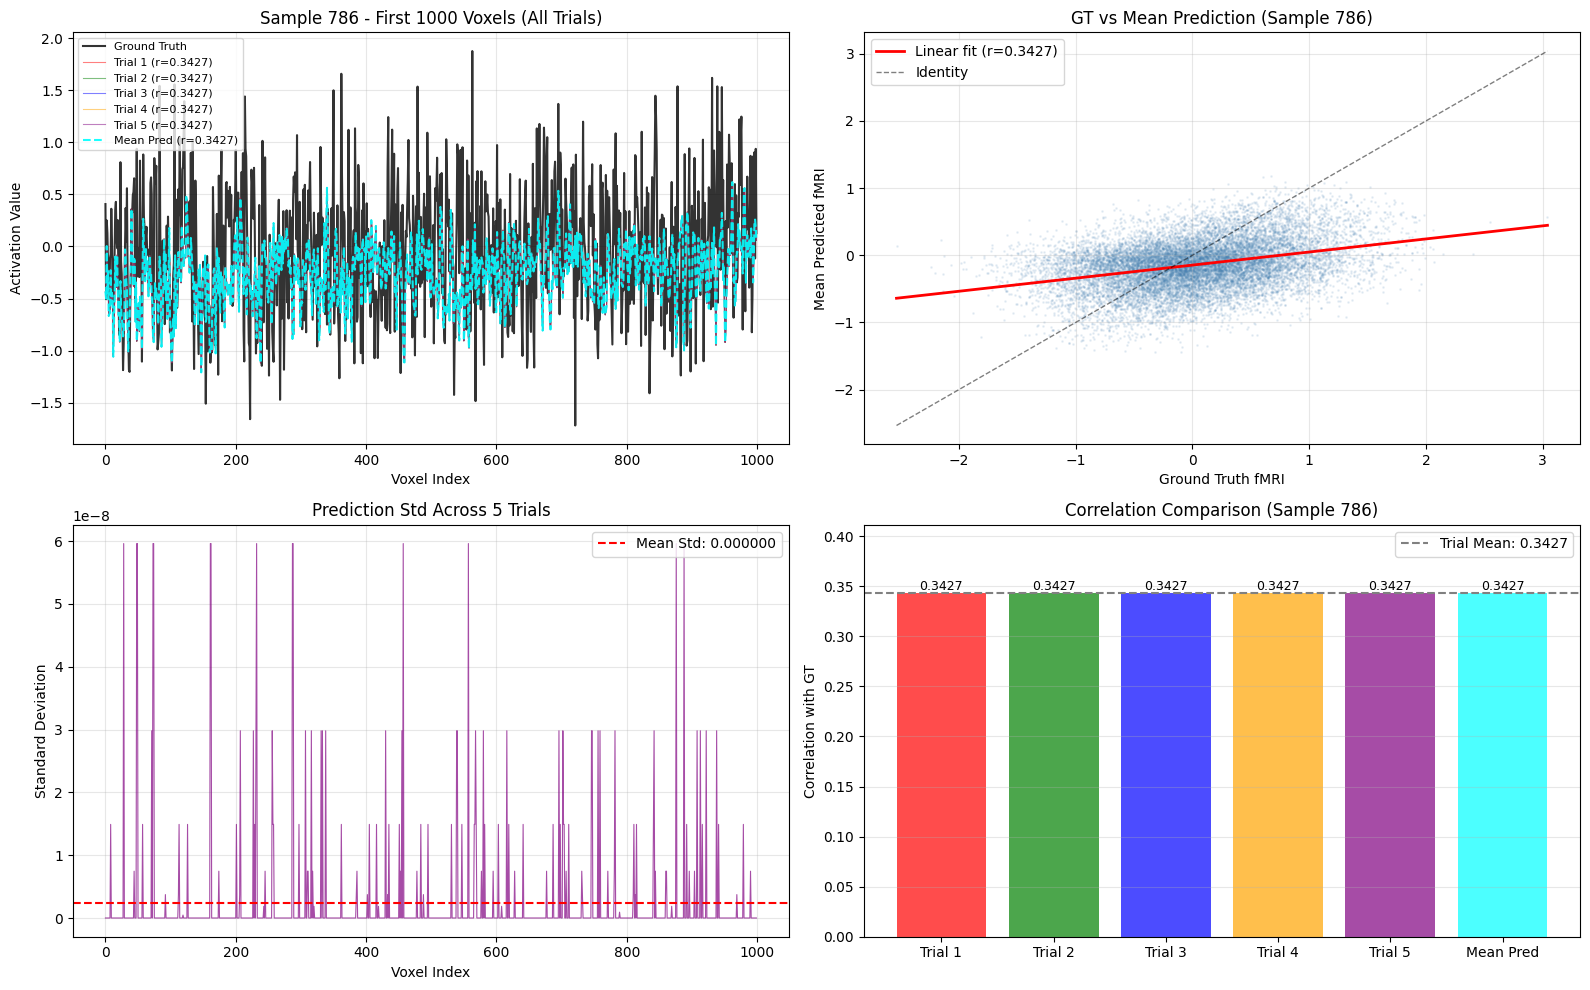

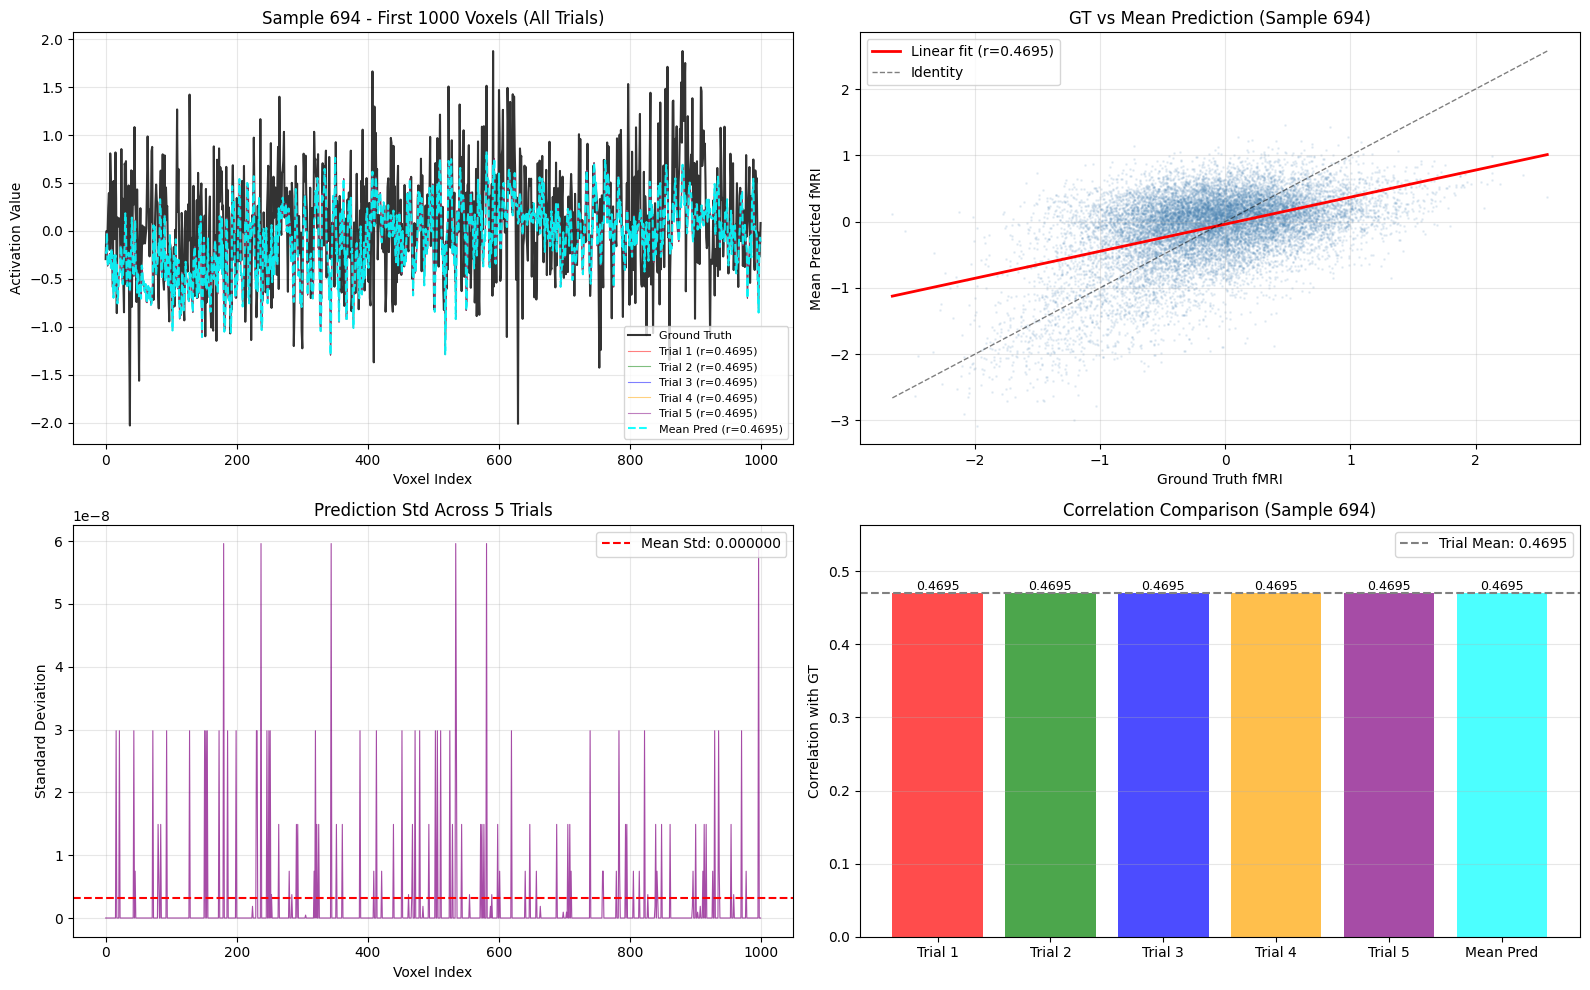

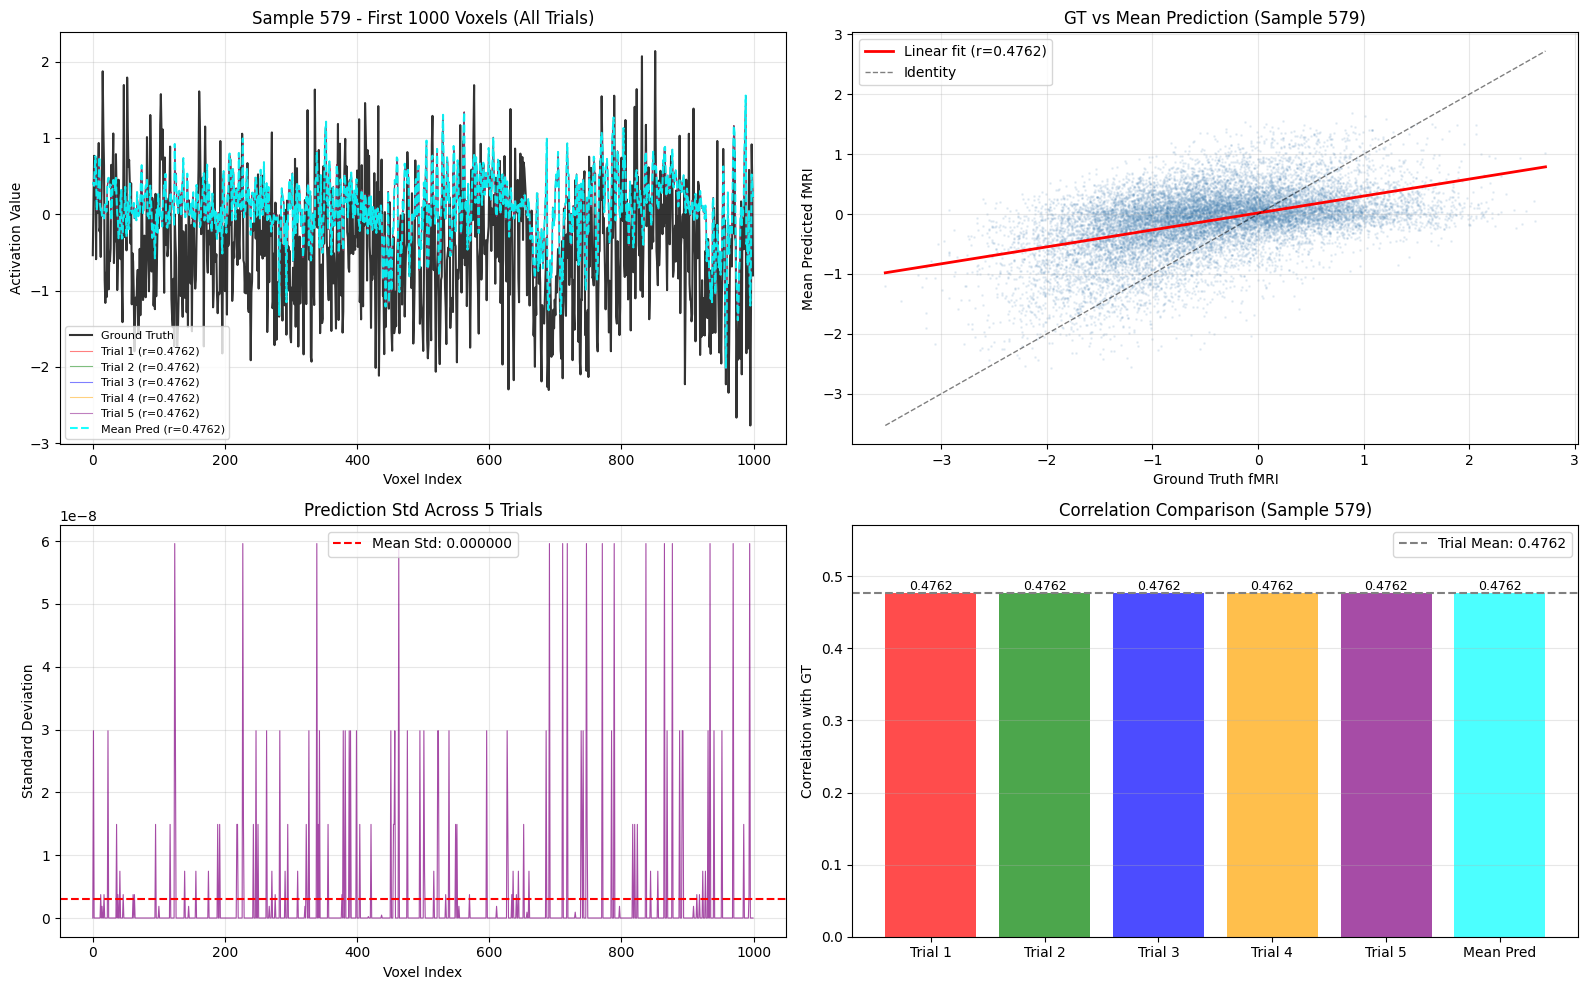

In [21]:
# Visualize multi-trial results for first 3 samples
print("Visualizing multi-trial comparisons...")
for idx in list(multi_trial_results.keys())[:3]:
    visualize_multi_trial_comparison(idx, multi_trial_results, num_trials=NUM_TRIALS)

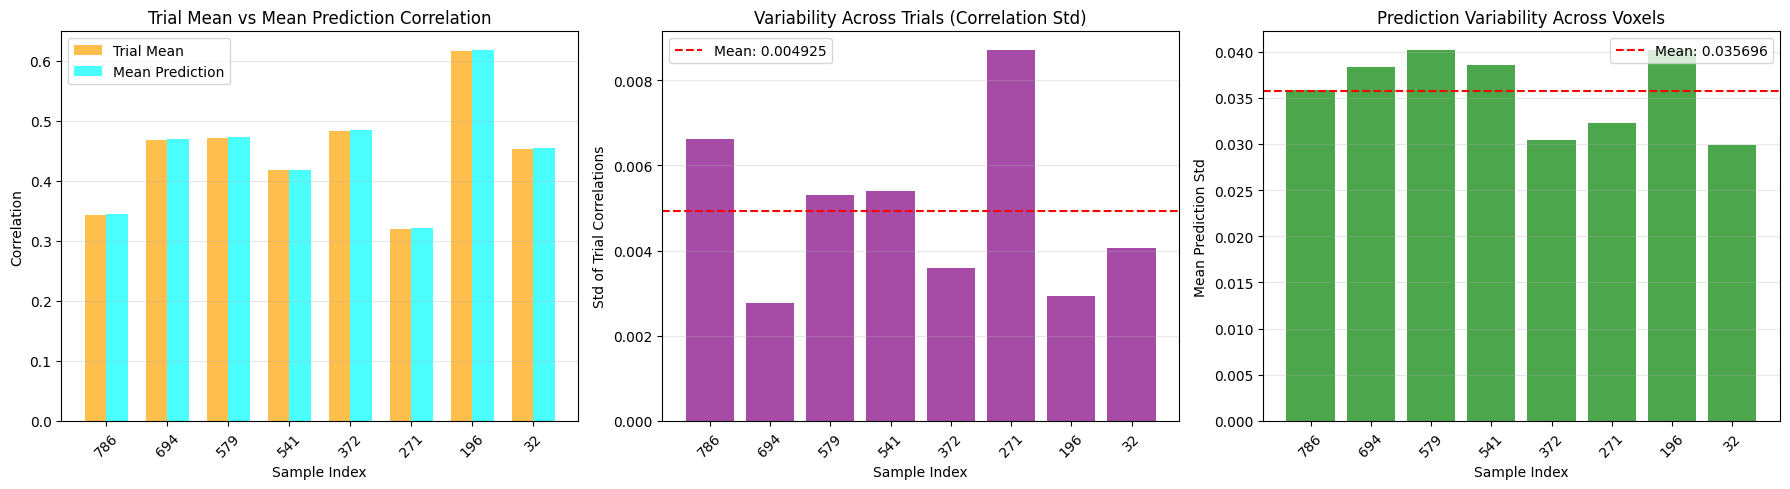


📊 Multi-trial analysis complete!


In [12]:
# Visualize overall trial variability statistics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Mean correlation distribution (across samples)
ax = axes[0]
x_pos = np.arange(len(multi_trial_results))
sample_indices = list(multi_trial_results.keys())
mean_corrs = [multi_trial_results[idx]['mean_correlation'] for idx in sample_indices]
trial_means = [multi_trial_results[idx]['trial_correlation_mean'] for idx in sample_indices]

width = 0.35
bars1 = ax.bar(x_pos - width/2, trial_means, width, label='Trial Mean', alpha=0.7, color='orange')
bars2 = ax.bar(x_pos + width/2, mean_corrs, width, label='Mean Prediction', alpha=0.7, color='cyan')

ax.set_xlabel('Sample Index')
ax.set_ylabel('Correlation')
ax.set_title('Trial Mean vs Mean Prediction Correlation')
ax.set_xticks(x_pos)
ax.set_xticklabels(sample_indices, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Trial correlation variability (std across trials)
ax = axes[1]
trial_stds = [multi_trial_results[idx]['trial_correlation_std'] for idx in sample_indices]
bars = ax.bar(x_pos, trial_stds, alpha=0.7, color='purple')
ax.axhline(np.mean(trial_stds), color='r', linestyle='--', 
          label=f'Mean: {np.mean(trial_stds):.6f}')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Std of Trial Correlations')
ax.set_title('Variability Across Trials (Correlation Std)')
ax.set_xticks(x_pos)
ax.set_xticklabels(sample_indices, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Prediction variability (mean std across voxels)
ax = axes[2]
pred_stds = [multi_trial_results[idx]['prediction_std_mean'] for idx in sample_indices]
bars = ax.bar(x_pos, pred_stds, alpha=0.7, color='green')
ax.axhline(np.mean(pred_stds), color='r', linestyle='--', 
          label=f'Mean: {np.mean(pred_stds):.6f}')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Mean Prediction Std')
ax.set_title('Prediction Variability Across Voxels')
ax.set_xticks(x_pos)
ax.set_xticklabels(sample_indices, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Multi-trial analysis complete!")

In [22]:
# Summary of multi-trial outputs
print("\n" + "="*90)
print("MULTI-TRIAL OUTPUT FILES SUMMARY")
print("="*90)
print(f"\nOutput directory: {OUTPUT_MULTI_TRIAL_DIR}/")
print(f"\nFile structure per sample:")
print(f"  - sample_XXXX_gt.nii           : Ground truth fMRI")
print(f"  - sample_XXXX_trial1_pred.nii  : Trial 1 prediction")
print(f"  - sample_XXXX_trial2_pred.nii  : Trial 2 prediction")
print(f"  - sample_XXXX_trial3_pred.nii  : Trial 3 prediction")
print(f"  - sample_XXXX_mean_pred.nii    : Mean of all trials (final prediction)")
print(f"  - sample_XXXX_std_pred.nii     : Standard deviation map across trials")

print(f"\nTotal files generated:")
files = sorted(os.listdir(OUTPUT_MULTI_TRIAL_DIR))
print(f"  {len(files)} files")

# Group by sample
sample_groups = {}
for f in files:
    if f.endswith('.nii'):
        sample_id = f.split('_')[1]
        if sample_id not in sample_groups:
            sample_groups[sample_id] = []
        sample_groups[sample_id].append(f)

print(f"\nFiles per sample:")
for sample_id in sorted(sample_groups.keys())[:3]:  # Show first 3
    print(f"\n  Sample {sample_id}:")
    for f in sorted(sample_groups[sample_id]):
        filepath = os.path.join(OUTPUT_MULTI_TRIAL_DIR, f)
        size_kb = os.path.getsize(filepath) / 1024
        print(f"    {f:<35s} {size_kb:>8.1f} KB")

if len(sample_groups) > 3:
    print(f"\n  ... and {len(sample_groups) - 3} more samples")

print("\n" + "="*90)
print("✅ Multi-trial inference completed successfully!")
print("="*90)


MULTI-TRIAL OUTPUT FILES SUMMARY

Output directory: ../outputs/inference_multi_trial_huwng/

File structure per sample:
  - sample_XXXX_gt.nii           : Ground truth fMRI
  - sample_XXXX_trial1_pred.nii  : Trial 1 prediction
  - sample_XXXX_trial2_pred.nii  : Trial 2 prediction
  - sample_XXXX_trial3_pred.nii  : Trial 3 prediction
  - sample_XXXX_mean_pred.nii    : Mean of all trials (final prediction)
  - sample_XXXX_std_pred.nii     : Standard deviation map across trials

Total files generated:
  64 files

Files per sample:

  Sample 0032:
    sample_0032_gt.nii                      61.8 KB
    sample_0032_mean_pred.nii               61.8 KB
    sample_0032_std_pred.nii                61.8 KB
    sample_0032_trial1_pred.nii             61.8 KB
    sample_0032_trial2_pred.nii             61.8 KB
    sample_0032_trial3_pred.nii             61.8 KB
    sample_0032_trial4_pred.nii             61.8 KB
    sample_0032_trial5_pred.nii             61.8 KB

  Sample 0196:
    sample_0196_g

---
# Part 4: Visualization

In [23]:
def visualize_fmri_comparison(idx, results):
    """Visualize GT fMRI vs Pred fMRI for a sample."""
    if idx not in results:
        print(f"Index {idx} not in results")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Load NIfTI files
    gt_nii = nib.load(results[idx]['gt_path'])
    pred_nii = nib.load(results[idx]['pred_path'])
    gt_data = gt_nii.get_fdata().flatten()
    pred_data = pred_nii.get_fdata().flatten()
    
    # Plot first 1000 voxels
    axes[0].plot(gt_data[:], 'b-', alpha=0.7, linewidth=0.8, label='Ground Truth')
    axes[0].plot(pred_data[:], 'r-', alpha=0.7, linewidth=0.8, label='Prediction')
    axes[0].set_title(f"Sample {idx} - First 1000 Voxels\nCorrelation: {results[idx]['correlation']:.4f}")
    axes[0].set_xlabel("Voxel Index")
    axes[0].set_ylabel("Activation Value")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Scatter plot GT vs Pred
    axes[1].scatter(gt_data, pred_data, alpha=0.1, s=1, c='steelblue')
    
    # Add regression line
    z = np.polyfit(gt_data, pred_data, 1)
    p = np.poly1d(z)
    x_range = np.linspace(gt_data.min(), gt_data.max(), 100)
    axes[1].plot(x_range, p(x_range), 'r-', linewidth=2, 
                label=f'Linear fit (r={results[idx]["correlation"]:.4f})')
    
    # Add identity line
    axes[1].plot([gt_data.min(), gt_data.max()], 
                [gt_data.min(), gt_data.max()], 
                'k--', alpha=0.5, linewidth=1, label='Identity')
    
    axes[1].set_xlabel('Ground Truth fMRI')
    axes[1].set_ylabel('Predicted fMRI')
    axes[1].set_title(f'GT vs Pred Scatter (Sample {idx})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def visualize_correlation_distribution(results):
    """Visualize distribution of correlations across all samples."""
    correlations = [r['correlation'] for r in results.values()]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(correlations, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(np.mean(correlations), color='r', linestyle='--', linewidth=2, 
              label=f'Mean: {np.mean(correlations):.4f}')
    ax.axvline(np.median(correlations), color='g', linestyle='--', linewidth=2,
              label=f'Median: {np.median(correlations):.4f}')
    
    ax.set_xlabel('Pearson Correlation')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of GT-Pred Correlations')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("✅ Visualization functions defined!")

✅ Visualization functions defined!


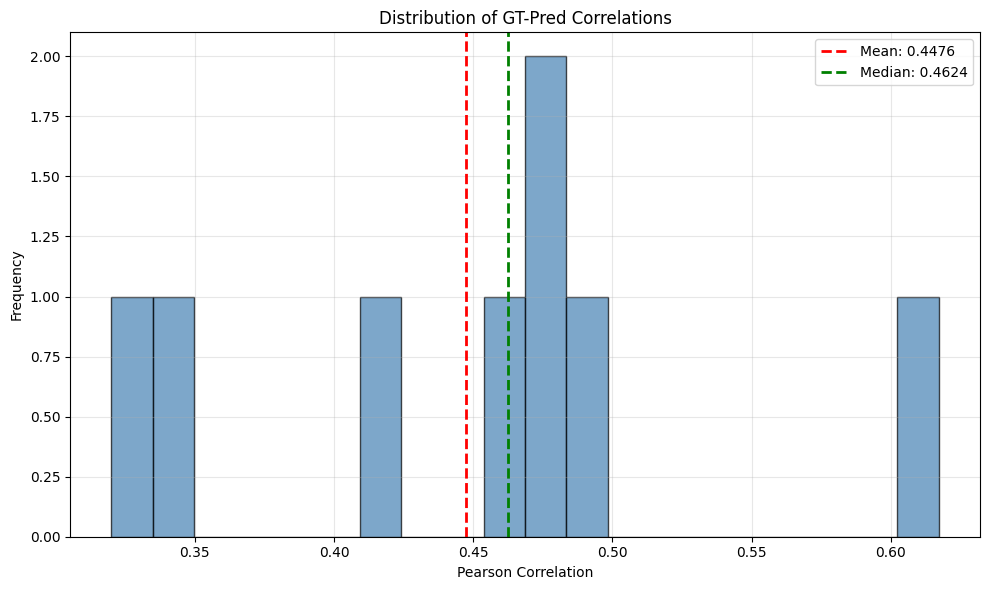

In [24]:
# Visualize correlation distribution
if len(results) > 1:
    visualize_correlation_distribution(results)

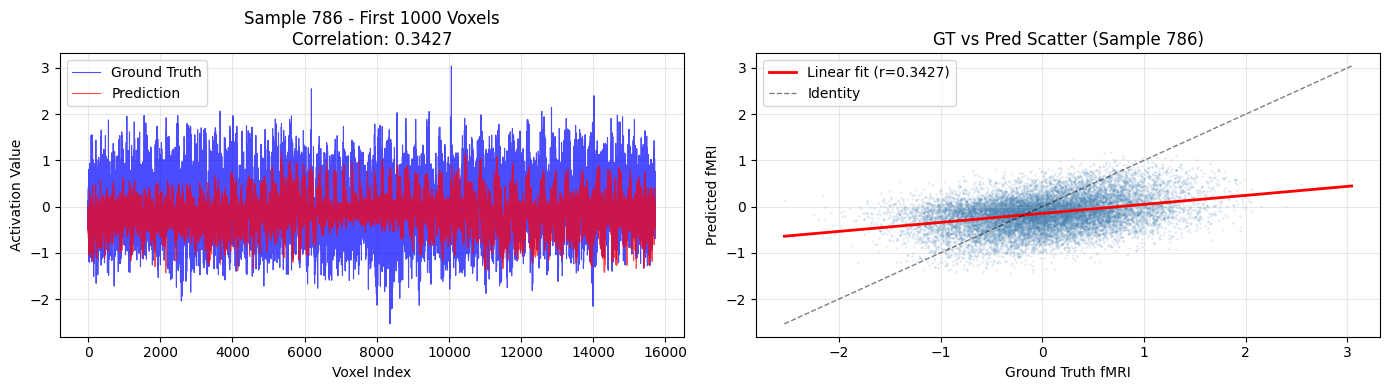

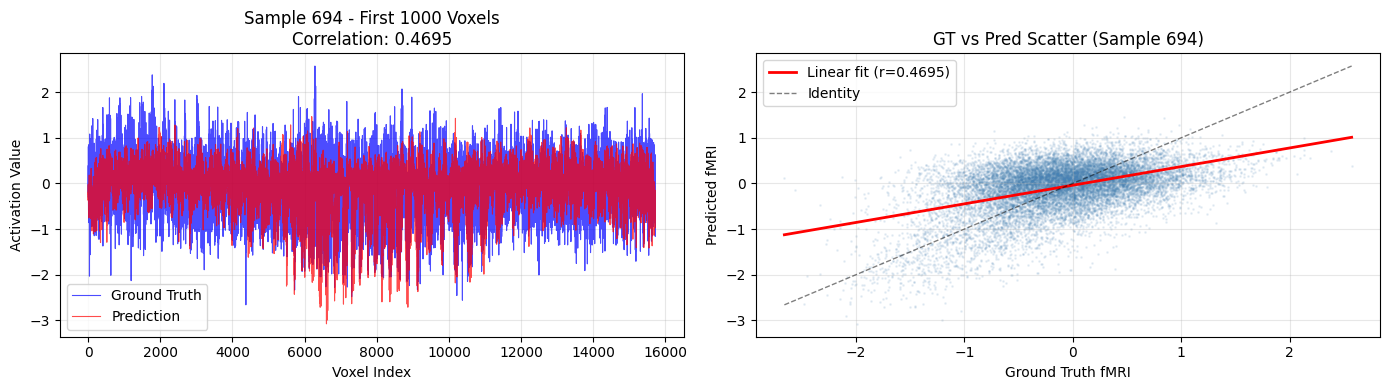

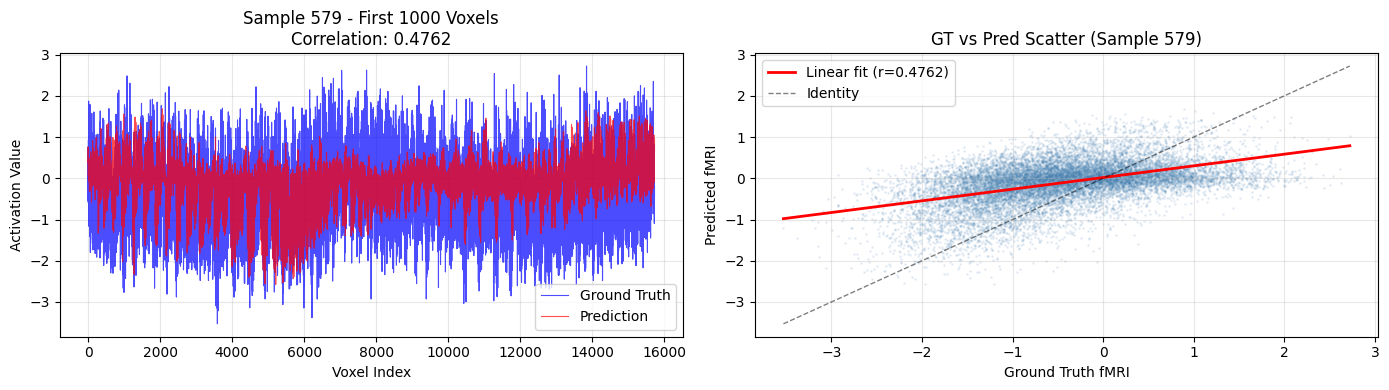

In [25]:
# Visualize individual samples (first 3)
for idx in list(results.keys())[:3]:
    visualize_fmri_comparison(idx, results)

In [26]:
# Summary
print("\n" + "="*70)
print("DONE!")
print("="*70)
print(f"Dataset: HUWNG subject {SUBJECT}")
print(f"Test samples: {len(test_dataset)}")
print(f"Inferred samples: {len(results)}")
print(f"NIfTI output: {OUTPUT_NII_DIR}/")
print(f"\nOutput files:")
for f in sorted(os.listdir(OUTPUT_NII_DIR)):
    filepath = os.path.join(OUTPUT_NII_DIR, f)
    size_kb = os.path.getsize(filepath) / 1024
    print(f"  {f:<30s} {size_kb:>8.1f} KB")

print("\n" + "="*70)
print("✅ Inference completed successfully!")
print("="*70)


DONE!
Dataset: HUWNG subject 1
Test samples: 1000
Inferred samples: 8
NIfTI output: ../outputs/inference_results_huwng/

Output files:
  sample_0032_gt.nii                 61.8 KB
  sample_0032_pred.nii               61.8 KB
  sample_0196_gt.nii                 61.8 KB
  sample_0196_pred.nii               61.8 KB
  sample_0271_gt.nii                 61.8 KB
  sample_0271_pred.nii               61.8 KB
  sample_0372_gt.nii                 61.8 KB
  sample_0372_pred.nii               61.8 KB
  sample_0541_gt.nii                 61.8 KB
  sample_0541_pred.nii               61.8 KB
  sample_0579_gt.nii                 61.8 KB
  sample_0579_pred.nii               61.8 KB
  sample_0694_gt.nii                 61.8 KB
  sample_0694_pred.nii               61.8 KB
  sample_0786_gt.nii                 61.8 KB
  sample_0786_pred.nii               61.8 KB

✅ Inference completed successfully!
